## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA

import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
np.random.seed(0)

In [2]:
# # 读取数据
# data_path = '/home/lqr/CLIMA/code/data/'
# sc = np.load(data_path + '/sc_data.npz')
# st = np.load(data_path + '/st_data.npz')

# # sc_data = [sc[key] for key in sc.files]
# # st_data = [st[key] for key in st.files]
# sc_data = [sc['sc_gene'], sc['sc_atac']]

In [3]:
from os.path import join
import pandas as pd

data_path = '/home/lqr/CLIMA/datasets/new_simu/'
# data1 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_Gene_counts.csv'), index_col=0)
data1 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_Gene_normalized.csv'), index_col=0)
# data3 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_PeakonGene_counts.csv'), index_col=0)
data2 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_PeakonGene_normalized.csv'), index_col=0)



In [4]:
# 转换成numpy数组
gene = data1.T.values
peak = data2.T.values
gene_peak = gene + peak

## Generate simulation data


Simulation parameters

In [5]:
latent_dim = 100
# num_cluster = 10
sample_size = 1000



Use simulation tool to generate multi-modality data

## Analyses based on single modality

Learn features from single modality

In [6]:
view_gene_feature = PCA(n_components=latent_dim).fit_transform(gene)
view_peak_feature = PCA(n_components=latent_dim).fit_transform(peak)
view_c_feature = PCA(n_components=latent_dim).fit_transform(gene_peak)

In [7]:
print(f"gene.shape: {gene.shape}")
print(f"peak.shape: {peak.shape}")
print(f"view_gene_feature.shape: {view_gene_feature.shape}")
print(f"view_peak_feature.shape: {view_peak_feature.shape}")

gene.shape: (3293, 21127)
peak.shape: (3293, 21127)
view_gene_feature.shape: (3293, 100)
view_peak_feature.shape: (3293, 100)


Perform clustering using PhenoGraph

In [8]:
view_a_label, _, _ = phenograph.cluster(view_gene_feature)
view_b_label, _, _ = phenograph.cluster(view_peak_feature)
view_c_label, _, _ = phenograph.cluster(view_c_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.12793517112731934 seconds
Jaccard graph constructed in 0.47272419929504395 seconds
Wrote graph to binary file in 0.013924360275268555 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.889004
After 4 runs, maximum modularity is Q = 0.890165
Louvain completed 24 runs in 1.4405722618103027 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.45538592338562 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.08115696907043457 seconds
Jaccard graph constructed in 0.4900686740875244 seconds
Wrote graph to binary file in 0.016643047332763672 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.286147
After 7 runs, maximum modularity is Q = 0.287267
Louvain completed 27 runs in 1.7306699752807617 seconds
Sorting communities by size, please wait 

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [20]:
outputs = muse.dual_muse_fit_predict(
    [gene],
    [gene_peak],
    [view_a_label],
    [view_c_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=1,
    weight_penalty=5,
    triplet_lambda=5,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
#epoch: 0/200 	 total loss: 994.78 	 sc loss: 497.50 	 st loss: 492.77 	 infoNCE: 4.51 	 sc recon: 0.04 	 st recon: 0.05 	 sc sparse: 497.46 	 st sparse: 492.73 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 50/200 	 total loss: 800.13 	 sc loss: 402.31 	 st loss: 397.75 	 infoNCE: 0.07 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 402.30 	 st sparse: 397.73 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 100/200 	 total loss: 632.98 	 sc loss: 318.58 	 st loss: 314.36 	 infoNCE: 0.03 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 318.57 	 st sparse: 314.35 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 150/200 	 total loss: 488.09 	 sc loss: 245.87 	 st loss: 242.19 	 infoNCE: 0.02 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 245.86 	 st sparse: 242.18 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 0/200 	 total loss: 391.09 	 sc loss: 194.07 	 st loss: 193.03 	 infoNCE: 3.99 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 184.31 	 st sparse

In [21]:
latent_sc = (outputs[0])
latent_st = (outputs[1])
reconstruct_sc = (outputs[2])
reconstruct_st = (outputs[3])
encoded_sc = (outputs[4])
encoded_st = (outputs[5])
print(f"latent_sc: {latent_sc.shape}")
print(f"latent_st: {latent_st.shape}")
print(f"reconstruct_sc: {reconstruct_sc.shape}")
print(f"reconstruct_st: {reconstruct_st.shape}")
print(f"encoded_sc: {encoded_sc.shape}")
print(f"encoded_st: {encoded_st.shape}")

latent_sc: (3293, 100)
latent_st: (3293, 100)
reconstruct_sc: (1, 3293, 21127)
reconstruct_st: (1, 3293, 21127)
encoded_sc: (1, 3293, 128)
encoded_st: (1, 3293, 128)


## Perform clustering
PhenoGraph clustering

In [22]:
latent_label_sc, _, _ = phenograph.cluster(latent_sc)
latent_label_st, _, _ = phenograph.cluster(latent_st)

label_true = view_c_label

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.08675360679626465 seconds
Jaccard graph constructed in 0.7450206279754639 seconds
Wrote graph to binary file in 0.0158078670501709 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.957084
Louvain completed 21 runs in 1.2688908576965332 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.8356029987335205 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.08177876472473145 seconds
Jaccard graph constructed in 0.7423639297485352 seconds
Wrote graph to binary file in 0.01291799545288086 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.946322
Louvain completed 21 runs in 1.0328238010406494 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.501365900039673 seconds


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

X_embedded: (3293, 2)
label_true: (3293,)


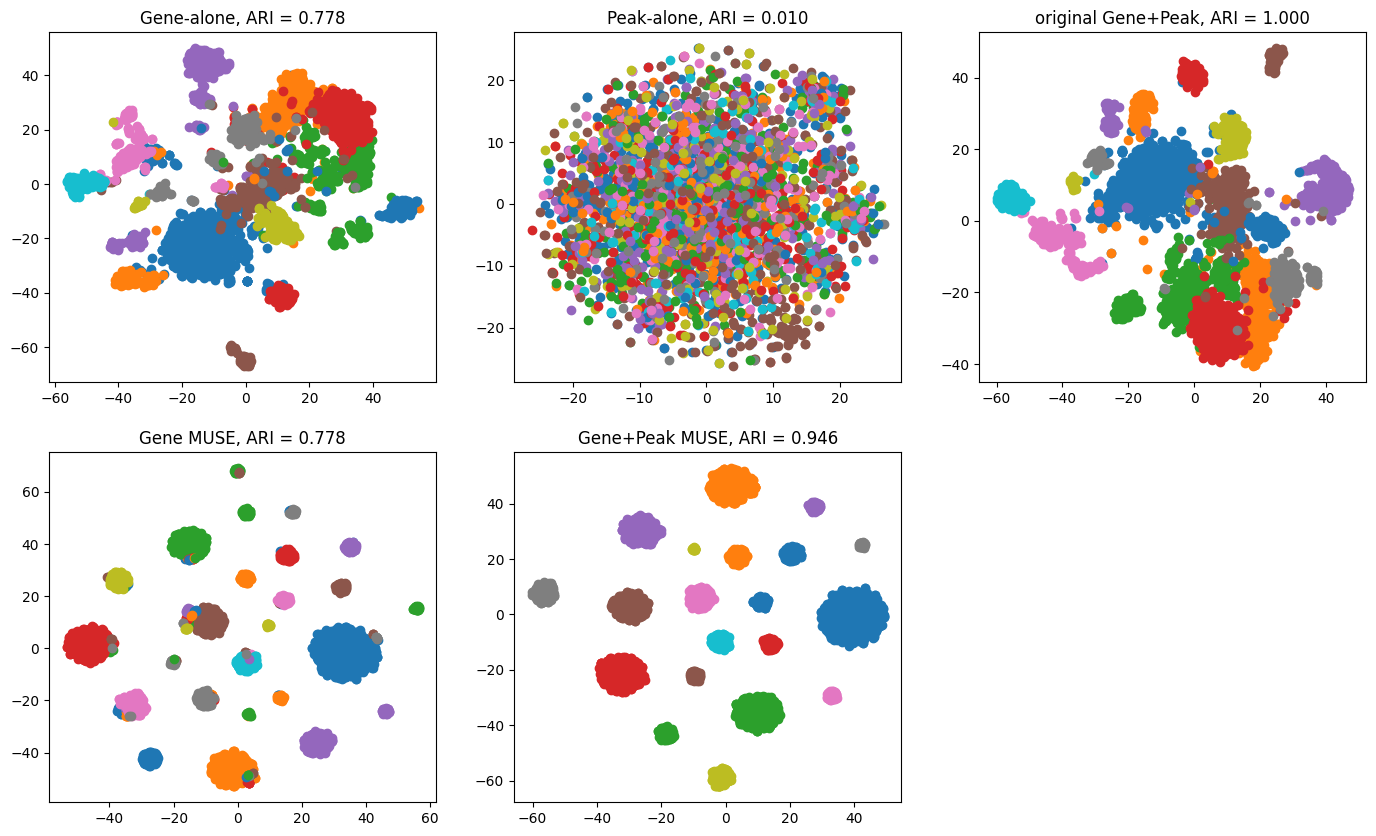

In [28]:
from matplotlib import gridspec

plt.figure(figsize=(17, 10))
gs = gridspec.GridSpec(2, 3)
# Gene-alone
plt.subplot(gs[0, 0])
X_embedded = TSNE(n_components=2).fit_transform(view_gene_feature)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {label_true.shape}")
# 遍历每一个类别
for i in np.unique(label_true):
    # 找到所有类别为i的索引
    idx = np.nonzero(label_true == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Gene-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_a_label))

# Peak-alone
plt.subplot(gs[0, 1])
X_embedded = TSNE(n_components=2).fit_transform(view_peak_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Peak-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_b_label))

# Gene, Peak MUSE(latent sc)
plt.subplot(gs[1, 0])
X_embedded = TSNE(n_components=2).fit_transform(latent_sc)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Gene MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, latent_label_sc))

# Peak+Gene MUSE(latent st)
plt.subplot(gs[1, 1])
X_embedded = TSNE(n_components=2).fit_transform(latent_st)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Gene+Peak MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, latent_label_st))

# original Gene+Peak
plt.subplot(gs[0, 2])
X_embedded = TSNE(n_components=2).fit_transform(view_c_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('original Gene+Peak, ARI = %01.3f' % adjusted_rand_score(label_true, view_c_label))
plt.show()


In [24]:
print('[gene, peak] and [gene+peak] ARI: ', adjusted_rand_score(latent_label_sc, latent_label_st))

[gene, peak] and [gene+peak] ARI:  0.8252125661849844


**************************************************
S: torch.Size([3293, 100, 1])
G: torch.Size([3293, 100, 1])


  0%|          | 0/500 [00:00<?, ?it/s]

 18%|█▊        | 92/500 [00:00<00:01, 220.29it/s]

Epoch 50: Loss -3043.824462890625


 28%|██▊       | 141/500 [00:00<00:01, 229.08it/s]

...

Epoch 400: Loss -3269.393310546875


 99%|█████████▉| 494/500 [00:02<00:00, 226.16it/s]

Epoch 450: Loss -3271.466064453125


100%|██████████| 500/500 [00:02<00:00, 224.24it/s]

Epoch 500: Loss -3273.096923828125
[[ 8.748745   -1.0578042   3.215103   ... -2.3564541  -0.36687282
  -0.21763994]
 [-1.6934447   5.1979394  -3.2138884  ... -0.28553292 -2.621431
  -1.7001394 ]
 [ 2.836012   -0.98747045 14.496024   ... -0.37805995 -2.0523603
  -2.6302836 ]
 ...
 [-0.48710126 -1.7795619  -1.6447088  ...  6.7015495  -1.6950195
   0.63275945]
 [-1.7618731  -1.293333   -1.6009058  ... -3.0628848  15.9334545
  -2.910024  ]
 [-1.4796407   0.82024443 -2.843421   ...  1.4017618  -0.8787205
   3.4112084 ]]


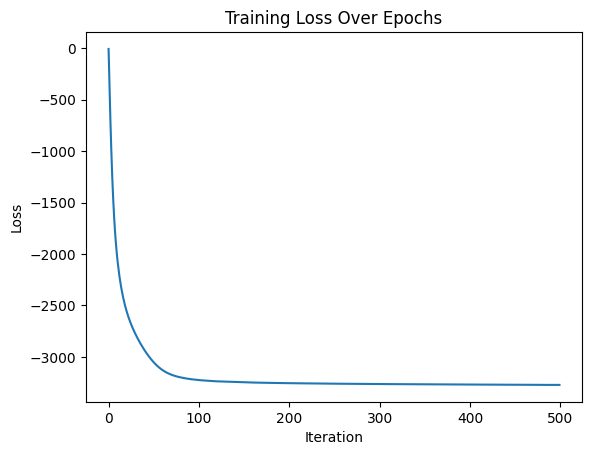

In [38]:
from sim_tangram.train_tangram import read_csv_and_run_tangram
import torch

# tangram
tangram_sim, _ = read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0')],
    [torch.tensor(latent_st, device='cuda:0')],
    # [torch.tensor(view_c_feature, device='cuda:0', dtype=torch.float32)],
    # [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=50,
    spotwise=True,
    genewise=True,
)

In [39]:
mapping = tangram_sim.argmax(axis=1)
for i in range(len(mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {mapping[i]:4d}", end="\t")


 0: 1295	 1:  693	 2:    2	 3:    3	 4: 1478	
 5:  980	 6: 2331	 7: 2690	 8:    8	 9: 1674	
10: 3030	11:   11	12:  184	13:   13	14:   34	
15: 2825	16:  128	17: 2016	18: 1156	19:   19	
20: 1744	21: 1398	22:   22	23: 1195	24: 2577	
25: 1044	26:  238	27: 2216	28: 1171	29: 1327	

In [40]:
# 计算latent_sc_muse和latent_st_muse的余弦相似度
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc, latent_st)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")


 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	

In [41]:
sample_size = tangram_sim.shape[0]
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
print("cos accuracy:", cos_acc)
tangram_acc = np.sum(mapping == gt) / sample_size
print("tangram accuracy:", tangram_acc)


cos accuracy: 1.0
tangram accuracy: 0.21591254175523839
